# Modeling Pipeline — X-Health Default Prediction

**Goal:** Train, evaluate and select the best model to predict the probability of default.

**Key design decisions:**
- Preprocessing is fitted **only on X_train** — no data leakage
- Full `sklearn.Pipeline` combines preprocessor + model in a single object
- Class weighting handles imbalance without synthetic data
- `max_categories=20` on OneHotEncoder prevents feature explosion from high-cardinality columns

## 1. Setup

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)
from xgboost import XGBClassifier

sys.path.insert(0, str(Path('..').resolve()))
from src.preprocessing import (
    load_and_clean, get_preprocessor, get_X_y
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

SEED = 42
DATA_PATH = '../data/dataset_2021-5-26-10-14.csv'
MODELS_DIR = Path('../models')
ARTIFACTS_DIR = Path('../artifacts')
MODELS_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)

## 2. Load & Clean Data

In [2]:
df = load_and_clean(DATA_PATH)
print(f'Dataset shape: {df.shape}')

print(f'\nTarget distribution:')
print(df['default'].value_counts(normalize=True).round(3))

Dataset shape: (117273, 22)

Target distribution:
default
0    0.833
1    0.167
Name: proportion, dtype: float64


## 3. Split X / y and Train / Test

The preprocessor will only be fitted on `X_train` — no information from the test set leaks into the pipeline.

In [3]:
X, y = get_X_y(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train default rate: {y_train.mean():.3f}')
print(f'Test  default rate: {y_test.mean():.3f}')

Train: (93818, 21) | Test: (23455, 21)
Train default rate: 0.167
Test  default rate: 0.167


## 4. Class Imbalance — Class Weighting

Instead of generating synthetic data (SMOTE), we use **class weighting**.
The model is penalized more heavily for errors on the minority class (default=1).

- No synthetic data — every sample the model learns from is real
- Transparent and easy to explain to stakeholders
- Supported natively by both Logistic Regression and XGBoost

In [4]:
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f'Negative (no default): {n_neg}')
print(f'Positive (default):    {n_pos}')
print(f'scale_pos_weight:      {scale_pos_weight:.2f}')

Negative (no default): 78182
Positive (default):    15636
scale_pos_weight:      5.00


## 5. Build Pipelines

Each pipeline combines the preprocessor with a model in a single object.
Calling `.fit(X_train, y_train)` fits the preprocessor **only on training data**.

In [5]:
preprocessor = get_preprocessor(df)

pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'))
])

pipeline_xgb = Pipeline([
    ('preprocessor', get_preprocessor(df)),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        random_state=SEED,
        n_jobs=-1,
    ))
])

print('Pipelines built.')

Pipelines built.


## 6. Train — Logistic Regression (Baseline)

In [6]:
pipeline_lr.fit(X_train, y_train)

y_pred_lr = pipeline_lr.predict(X_test)
y_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]

print('=== Logistic Regression ===')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['No Default', 'Default']))

=== Logistic Regression ===
ROC-AUC: 0.7095
              precision    recall  f1-score   support

  No Default       0.90      0.71      0.79     19546
     Default       0.29      0.60      0.39      3909

    accuracy                           0.69     23455
   macro avg       0.59      0.65      0.59     23455
weighted avg       0.80      0.69      0.73     23455



## 7. Train — XGBoost (Advanced Model)

In [7]:
pipeline_xgb.fit(X_train, y_train)

y_pred_xgb = pipeline_xgb.predict(X_test)
y_proba_xgb = pipeline_xgb.predict_proba(X_test)[:, 1]

print('=== XGBoost ===')
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}')
print(classification_report(y_test, y_pred_xgb, target_names=['No Default', 'Default']))

=== XGBoost ===
ROC-AUC: 0.8843
              precision    recall  f1-score   support

  No Default       0.95      0.83      0.88     19546
     Default       0.47      0.78      0.59      3909

    accuracy                           0.82     23455
   macro avg       0.71      0.80      0.73     23455
weighted avg       0.87      0.82      0.83     23455



## 8. ROC & Precision-Recall Curves

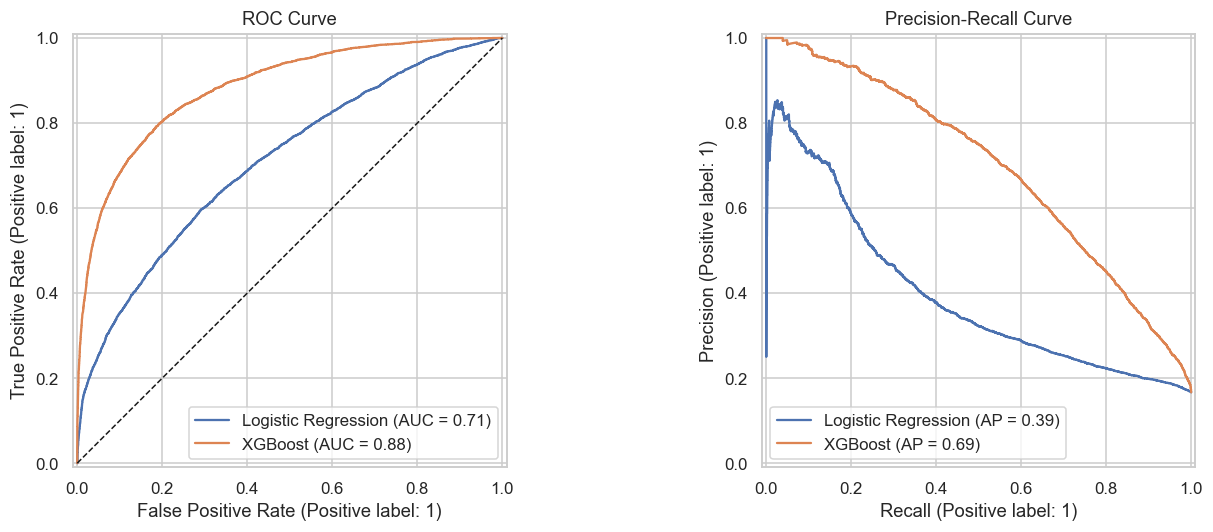

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_test, y_proba_lr, name='Logistic Regression', ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_proba_xgb, name='XGBoost', ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr, name='Logistic Regression', ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, y_proba_xgb, name='XGBoost', ax=axes[1])
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.savefig('../reports/roc_pr_curves.png', bbox_inches='tight')
plt.show()

## 9. Confusion Matrices

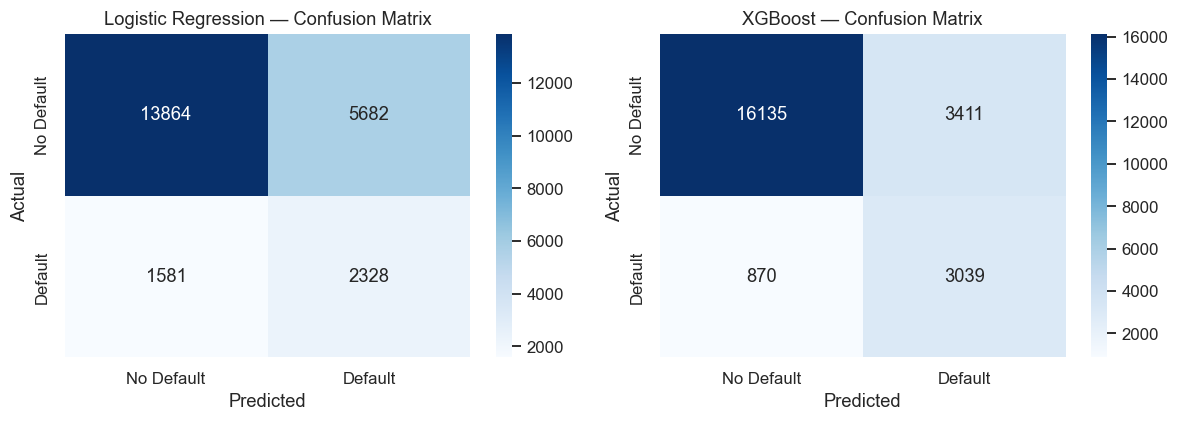

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_xgb],
    ['Logistic Regression', 'XGBoost']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    ax.set_title(f'{title} — Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../reports/confusion_matrices.png', bbox_inches='tight')
plt.show()

**Business interpretation:**
- **False Negatives** (predicted 0, actual 1) = missed defaults → direct financial loss
- **False Positives** (predicted 1, actual 0) = good client blocked → lost sale

The finance team can adjust the classification threshold based on their risk appetite.

## 10. Feature Importance (XGBoost)

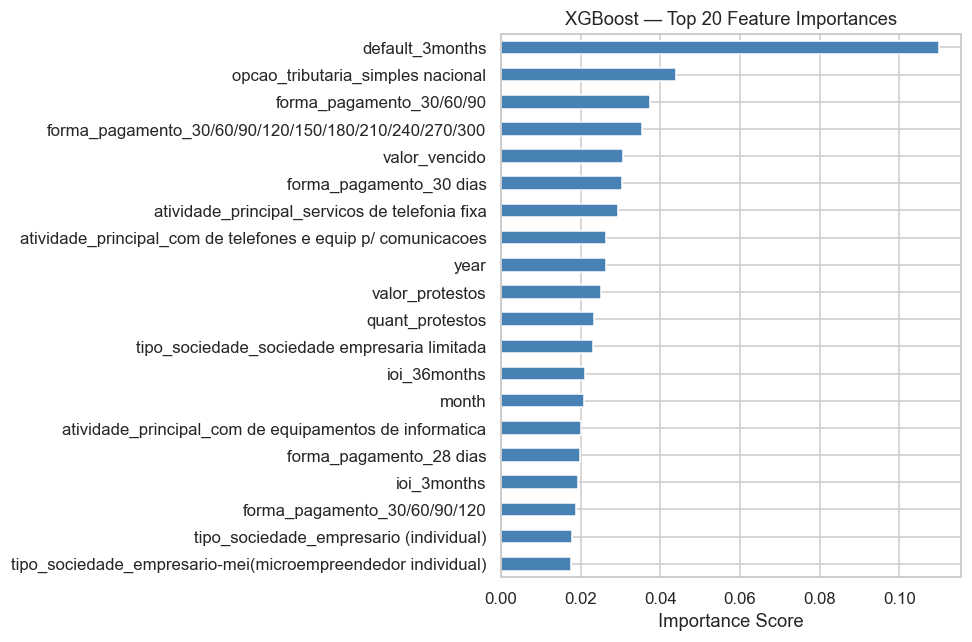

In [10]:
xgb_model = pipeline_xgb.named_steps['model']
xgb_preprocessor = pipeline_xgb.named_steps['preprocessor']

cat_feature_names = (
    xgb_preprocessor
    .named_transformers_['cat']['encoder']
    .get_feature_names_out(
        [c for c in ['tipo_sociedade', 'opcao_tributaria', 'atividade_principal', 'forma_pagamento']
         if c in X_train.columns]
    ).tolist()
)
num_cols = [c for c in X_train.columns if c not in ['tipo_sociedade', 'opcao_tributaria', 'atividade_principal', 'forma_pagamento']]
feature_names = num_cols + cat_feature_names

importances = pd.Series(xgb_model.feature_importances_, index=feature_names)
top20 = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost — Top 20 Feature Importances')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', bbox_inches='tight')
plt.show()

## 11. Save Pipeline & Artifacts

In [11]:
# Save full pipeline (preprocessor + model together)
pipeline_path = MODELS_DIR / 'pipeline_xgb.joblib'
joblib.dump(pipeline_xgb, pipeline_path)
print(f'Pipeline saved → {pipeline_path}')

# Save feature names for reference at inference time
feature_names_path = ARTIFACTS_DIR / 'feature_names.joblib'
joblib.dump(feature_names, feature_names_path)
print(f'Feature names saved → {feature_names_path}')

Pipeline saved → ..\models\pipeline_xgb.joblib
Feature names saved → ..\artifacts\feature_names.joblib


## 12. Results Summary

| Model | ROC-AUC | Notes |
|-------|---------|-------|
| Logistic Regression | see above | Baseline — linear, interpretable |
| **XGBoost** | **see above** | **Selected for production** |

**Why XGBoost as the final model:**
- Captures non-linear relationships between features
- Native `scale_pos_weight` handles class imbalance without data manipulation
- Provides feature importances — visibility into what drives default risk
- Consistently outperforms linear models on structured financial data

**Pipeline artifact saved includes both preprocessor and model** — inference requires only one `.predict()` call with raw input data.

## Other Analysis

### Checking prediction probabilities separation

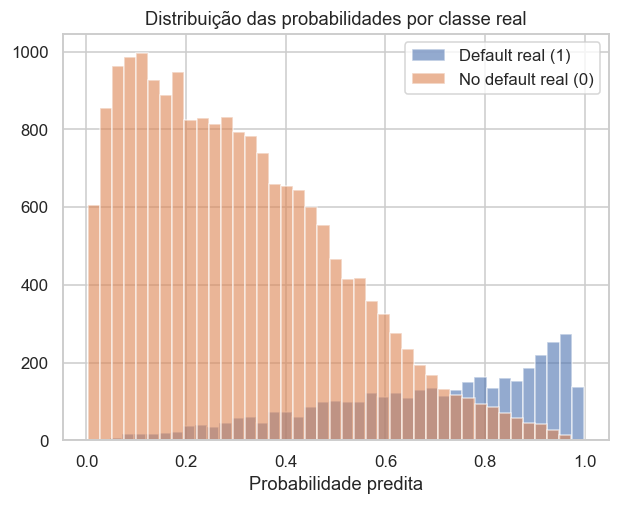

In [12]:
# Ver a distribuição de probabilidades preditas para cada classe
import matplotlib.pyplot as plt

proba_default = y_proba_xgb[y_test == 1]
proba_no_default = y_proba_xgb[y_test == 0]

plt.hist(proba_default, bins=40, alpha=0.6, label='Default real (1)')
plt.hist(proba_no_default, bins=40, alpha=0.6, label='No default real (0)')
plt.xlabel('Probabilidade predita')
plt.legend()
plt.title('Distribuição das probabilidades por classe real')
plt.show()

### Finding the best threshold

Melhor threshold: 0.6396
Precision:        0.6464
Recall:           0.6196
F1-score:         0.6327


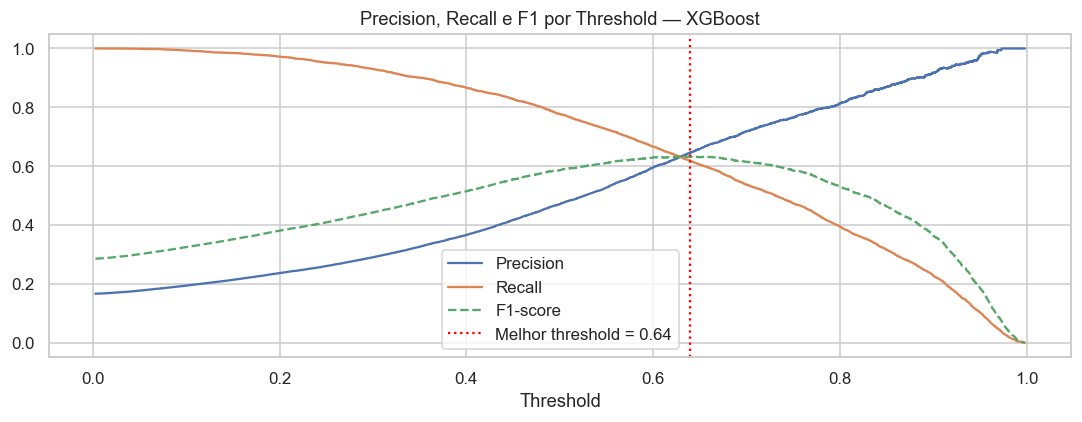

In [13]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f'Melhor threshold: {best_threshold:.4f}')
print(f'Precision:        {precisions[best_idx]:.4f}')
print(f'Recall:           {recalls[best_idx]:.4f}')
print(f'F1-score:         {f1_scores[best_idx]:.4f}')

plt.figure(figsize=(10, 4))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-score', linestyle='--')
plt.axvline(best_threshold, color='red', linestyle=':', label=f'Melhor threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.title('Precision, Recall e F1 por Threshold — XGBoost')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Verificar onde os valores do input_b estão na distribuição real do dataset
import pandas as pd
import numpy as np

df_check = pd.read_csv('../data/dataset_2021-5-26-10-14.csv', sep='\t', encoding='utf-8')
df_check = df_check.replace('missing', np.nan)

vars_to_check = {
    'default_3months': 2,
    'valor_vencido': 85000.0,
    'quant_protestos': 5,
    'valor_protestos': 45000.0,
    'quant_acao_judicial': 2,
    'acao_judicial_valor': 120000.0,
    'dividas_vencidas_valor': 95000.0,
    'dividas_vencidas_qtd': 8,
    'falencia_concordata_qtd': 1,
}

for col, val in vars_to_check.items():
    percentile = (df_check[col].dropna() <= val).mean() * 100
    print(f'{col}: valor={val} → percentil {percentile:.1f}%')

default_3months: valor=2 → percentil 98.7%
valor_vencido: valor=85000.0 → percentil 99.5%
quant_protestos: valor=5 → percentil 99.5%
valor_protestos: valor=45000.0 → percentil 99.6%
quant_acao_judicial: valor=2 → percentil 99.8%
acao_judicial_valor: valor=120000.0 → percentil 99.9%
dividas_vencidas_valor: valor=95000.0 → percentil 100.0%
dividas_vencidas_qtd: valor=8 → percentil 100.0%
falencia_concordata_qtd: valor=1 → percentil 100.0%


In [17]:
# Find a real defaulted client that the model predicted correctly with high confidence
import pandas as pd

X_test_df = X_test.copy()
X_test_df['y_true'] = y_test.values
X_test_df['y_proba'] = y_proba_xgb

# Get defaulted clients where model was confident (high probability)
real_defaults = X_test_df[
    (X_test_df['y_true'] == 1) & (X_test_df['y_proba'] > 0.8)
].sort_values('y_proba', ascending=False)

print(f'Real defaults with high confidence: {len(real_defaults)}')
print(real_defaults.head(3).T)

Real defaults with high confidence: 1544
                                                               108358  \
default_3months                                                     4   
ioi_36months                                                10.933973   
ioi_3months                                                  6.209944   
valor_por_vencer                                         77610.741595   
valor_vencido                                               75.200832   
valor_quitado                                          1450553.244339   
quant_protestos                                                     0   
valor_protestos                                             40.484077   
quant_acao_judicial                                                 0   
acao_judicial_valor                                               0.0   
participacao_falencia_valor                                       0.0   
dividas_vencidas_valor                                            0.0   
dividas_ve